# Ajedrez online — Entrega 2: análisis exploratorio e hipótesis

Este notebook estudia qué contienen las partidas obtenidas de la **PubAPI pública de Chess.com** y toma decisiones para la etapa de modelado. La unidad de análisis es una partida *rated* de ajedrez estándar en modalidad bullet, blitz o rapid. Los datos se consultan bajo las condiciones de uso de la PubAPI y no se redistribuyen en Git: se regeneran con el pipeline del proyecto.

El pipeline de Airflow de la Entrega 1 produce `data/processed/partidas_ajedrez_clean.parquet`; este notebook consume ese artefacto, sin descargar ni modificar datos. El recorrido responde cuatro preguntas: perfil y calidad, distribución de los objetivos, contraste de cuatro hipótesis y selección de columnas sin fuga de información.

## 1 · Configuración y carga

Se usan únicamente dependencias ya declaradas en `requirements.txt`. Las rutas funcionan tanto al abrir Jupyter desde la raíz del repositorio como desde `notebooks/`. Se fija una semilla para que la muestra visual de H2 sea reproducible.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "partidas_ajedrez_clean.parquet"
RANDOM_STATE = 42
RESULT_ORDER = ["Gana Blancas", "Empate", "Gana Negras"]
TIME_ORDER = ["bullet", "blitz", "rapid"]
COLORS = {"Gana Blancas": "#d9d9d9", "Empate": "#f4b942", "Gana Negras": "#3b3b3b"}

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró {DATA_PATH}. Ejecutar primero el DAG de Airflow para generar la muestra ampliada."
    )

df = pd.read_parquet(DATA_PATH)
print(f"Dataset cargado: {df.shape[0]:,} partidas × {df.shape[1]} columnas")
print(f"Período observado: {df['Date'].min():%d/%m/%Y} — {df['Date'].max():%d/%m/%Y}")

Dataset cargado: 80,145 partidas × 25 columnas
Período observado: 06/01/2013 — 01/09/2026


## 2 · Perfil y calidad del dataset

Antes de buscar relaciones se verifica qué representa cada fila y si existen problemas capaces de invalidar el análisis. `GameUrl` es la clave de la partida. No se hacen uniones en este notebook, por lo que no existe riesgo de *fan-out* adicional.

In [2]:
type_counts = df.dtypes.astype(str).value_counts().rename_axis("tipo").to_frame("columnas")
profile = pd.DataFrame(
    {
        "medida": [
            "Filas",
            "Columnas",
            "Duplicados de GameUrl",
            "Nulos totales",
            "Columnas constantes",
            "Usuarios distintos",
        ],
        "resultado": [
            len(df),
            df.shape[1],
            int(df["GameUrl"].duplicated().sum()),
            int(df.isna().sum().sum()),
            ", ".join(df.columns[df.nunique(dropna=False) <= 1]),
            pd.concat([df["White"], df["Black"]], ignore_index=True).nunique(),
        ],
    }
)
display(profile)
display(type_counts)

,medida,resultado
0,Filas,80145
1,Columnas,25
2,Duplicados de GameUrl,0
3,Nulos totales,0
4,Columnas constantes,"Event, Variant, Rated"
5,Usuarios distintos,53761


,columnas
tipo,
category,8
str,7
int16,4
datetime64[us],1
bool,1
Int16,1
Float64,1
float64,1
int8,1


In [3]:
column_profile = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "nulos": df.isna().sum(),
        "porcentaje_nulos": df.isna().mean().mul(100),
        "valores_unicos": df.nunique(dropna=False),
    }
).sort_values(["porcentaje_nulos", "valores_unicos"], ascending=[False, True])
display(column_profile)

,dtype,nulos,porcentaje_nulos,valores_unicos
Event,category,0,0.000,1
Variant,str,0,0.000,1
Rated,bool,0,0.000,1
es_sorpresa,int8,0,0.000,2
Result,str,0,0.000,3
TimeClass,category,0,0.000,3
resultado,category,0,0.000,3
nivel_promedio,category,0,0.000,5
familia_apertura,category,0,0.000,5
incremento_seg,Float64,0,0.000,8


**Lectura de calidad.** No hay nulos porque el pipeline descarta antes las filas sin resultado, fecha o ELO válidos, las partidas no *rated* o no estándar y los registros con menos de 5 medio-movimientos. Esto no significa que la fuente nunca tenga faltantes: significa que las columnas críticas tienen una política de filtrado explícita. `Event`, `Variant` y `Rated` son constantes después de aplicar el universo de estudio y deben salir del modelo.

La fecha máxima requiere explicación: `until_month: 2026-08` limita el archivo mensual consultado, pero Chess.com incluyó en sus archivos de agosto **56 partidas (0,07 % del dataset) fechadas el 1 de septiembre UTC**. Aparecen en varias cuentas y corresponden al límite horario del archivo mensual, no a un error del filtro. Se conservan porque son casos reales trazables, no fechas imposibles ni errores de parseo.

In [4]:
monthly_boundary = df.loc[
    df["Date"] > pd.Timestamp("2026-08-31"),
    ["GameUrl", "Date", "White", "Black", "TimeClass"],
]
boundary_summary = pd.DataFrame(
    {
        "partidas": [len(monthly_boundary)],
        "porcentaje_dataset": [len(monthly_boundary) / len(df) * 100],
        "fecha_minima": [monthly_boundary["Date"].min()],
        "fecha_maxima": [monthly_boundary["Date"].max()],
    }
)
display(boundary_summary)
display(monthly_boundary.head(10))
display(monthly_boundary["TimeClass"].value_counts().to_frame("partidas"))

,partidas,porcentaje_dataset,fecha_minima,fecha_maxima
0,56,0.070,2026-09-01,2026-09-01


,GameUrl,Date,White,Black,TimeClass
1907,https://www.chess.com/game/live/173825662426,2026-09-01,AleMLira78,sohrab1121,rapid
1908,https://www.chess.com/game/live/173825504834,2026-09-01,Isthat_clyde,AleMLira78,rapid
1909,https://www.chess.com/game/live/173825337100,2026-09-01,nnaaqa,AleMLira78,rapid
1910,https://www.chess.com/game/live/173825019306,2026-09-01,AleMLira78,Sorges17,rapid
1911,https://www.chess.com/game/live/173824776044,2026-09-01,fauzan28-nzm,AleMLira78,rapid
1912,https://www.chess.com/game/live/173824530586,2026-09-01,AleMLira78,Anubhavpandit7588,rapid
1913,https://www.chess.com/game/live/173824149890,2026-09-01,VinceVega24,AleMLira78,rapid
3912,https://www.chess.com/game/live/173821132382,2026-09-01,oldmanmississippi,ale-jr16,rapid
6667,https://www.chess.com/game/live/173825399606,2026-09-01,Lilurimini,Adolet4Russa,blitz
6668,https://www.chess.com/game/live/173825223716,2026-09-01,henddrr,Adolet4Russa,blitz


,partidas
TimeClass,
blitz,29
rapid,15
bullet,12


## 3 · Distribución de los objetivos

El proyecto tiene dos objetivos: `resultado` para clasificación multiclase y `cantidad_jugadas` para regresión. El balance de clases condiciona las métricas de la Entrega 3; para la duración importan la forma, la mediana y la cola, no solamente la media.

,partidas,porcentaje
resultado,,
Gana Blancas,39234,48.954
Empate,4897,6.110
Gana Negras,36014,44.936


,cantidad_jugadas
count,"80,145.000"
mean,75.228
std,33.487
min,5.000
25%,51.000
50%,71.000
75%,96.000
95%,136.000
max,375.000


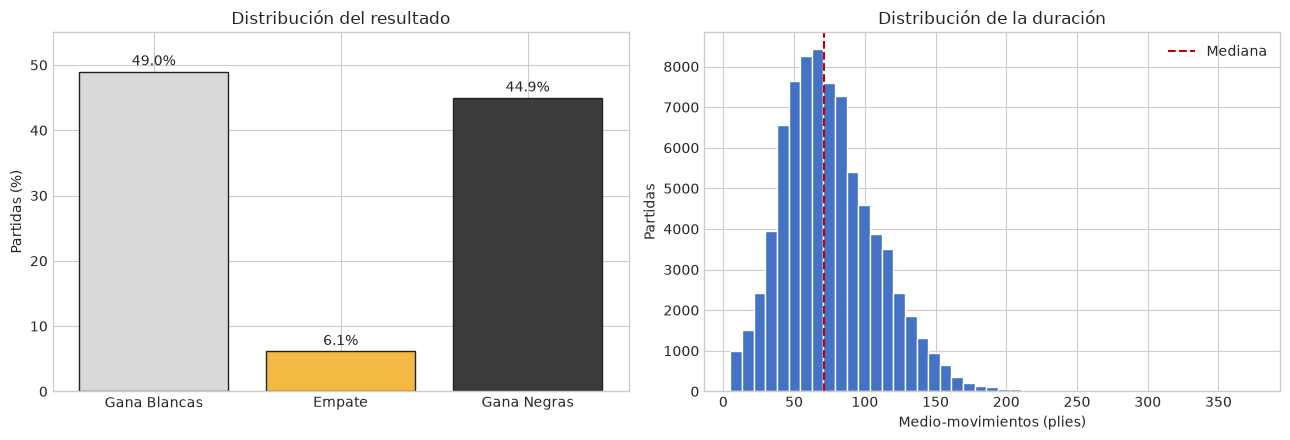

In [5]:
result_distribution = (
    df["resultado"]
    .value_counts()
    .reindex(RESULT_ORDER)
    .to_frame("partidas")
)
result_distribution["porcentaje"] = result_distribution["partidas"].div(len(df)).mul(100)
duration_summary = df["cantidad_jugadas"].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).to_frame("cantidad_jugadas")
display(result_distribution)
display(duration_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(
    result_distribution.index,
    result_distribution["porcentaje"],
    color=[COLORS[label] for label in result_distribution.index],
    edgecolor="#222222",
)
axes[0].set(title="Distribución del resultado", ylabel="Partidas (%)", xlabel="")
axes[0].set_ylim(0, 55)
for index, value in enumerate(result_distribution["porcentaje"]):
    axes[0].text(index, value + 1, f"{value:.1f}%", ha="center")

axes[1].hist(df["cantidad_jugadas"], bins=45, color="#4472c4", edgecolor="white")
axes[1].axvline(df["cantidad_jugadas"].median(), color="#c00000", linestyle="--", label="Mediana")
axes[1].set(title="Distribución de la duración", xlabel="Medio-movimientos (plies)", ylabel="Partidas")
axes[1].legend()
plt.tight_layout()
plt.show()

Blancas y negras están relativamente equilibradas (49,0 % y 44,9 %), pero **Empate representa sólo 6,11 %**. En modelado no alcanzará con *accuracy*: habrá que informar métricas por clase y vigilar especialmente recall/F1 de Empate. La duración tiene media 75,2 y mediana 71 plies, con una cola derecha moderada hasta 375; no se eliminan partidas largas porque son casos posibles del dominio.

### Asimetría y cobertura por nivel

La asimetría ayuda a anticipar transformaciones. En particular, `tiempo_base_seg` (3,84) e `incremento_seg` (5,69) concentran controles comunes cerca de cero y tienen una cola de controles menos frecuentes; en la Entrega 3 se compararán en escala logarítmica o discretizados. La distribución por nivel comprueba la cobertura que da la selección por bandas de ELO: las cinco bandas quedan entre 18,2 % y 21,8 % del dataset, sin ninguna dominante. Es un cambio cualitativo respecto de las versiones anteriores de la muestra, donde más de la mitad de las partidas caían en `top_mundial`.

,asimetria
elo_promedio,-0.461
BlackElo,-0.452
WhiteElo,-0.451
diferencia_elo,-0.297
cantidad_jugadas,0.663
es_sorpresa,1.210
tiempo_base_seg,3.842
incremento_seg,5.688


,porcentaje
nivel_promedio,
intermedio,21.839
principiante,21.240
top_mundial,19.855
experto,18.832
avanzado,18.233


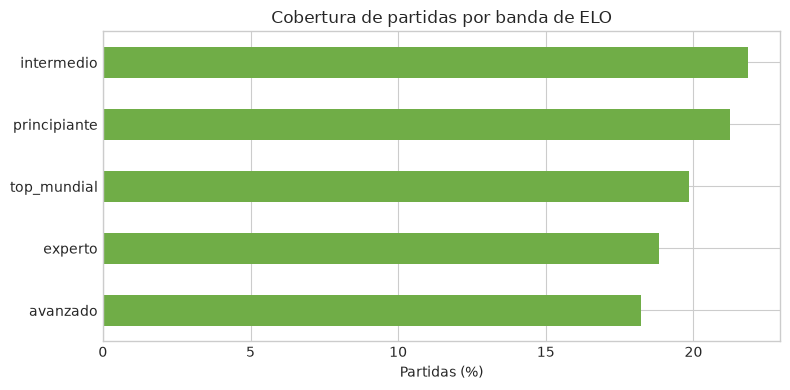

In [6]:
numeric_skew = df.select_dtypes(include="number").skew().sort_values().to_frame("asimetria")
level_distribution = (
    df["nivel_promedio"].value_counts(normalize=True).mul(100).to_frame("porcentaje")
)
display(numeric_skew)
display(level_distribution)

ax = level_distribution.sort_values("porcentaje").plot.barh(
    y="porcentaje", legend=False, color="#70ad47", figsize=(8, 4)
)
ax.set(title="Cobertura de partidas por banda de ELO", xlabel="Partidas (%)", ylabel="")
plt.tight_layout()
plt.show()

## 4 · Método para evaluar las hipótesis

Cada ficha declara la afirmación antes del resultado, usa sólo dos variables y termina en una decisión. Para asociaciones entre una variable numérica y grupos se usa η²: proporción de variabilidad numérica explicada por las diferencias entre grupos. Cuando ambas variables son categóricas se usa V de Cramér. Para correlaciones se informan Pearson (relación lineal) y Spearman (relación monótona).

Semáforo descriptivo usado de forma consistente:

- 🔴 efecto débil: `|r| < 0,10`, `V < 0,10` o `η² < 0,06`;
- 🟡 efecto moderado: `0,10 ≤ |r|, V < 0,30` o `0,06 ≤ η² < 0,14`;
- 🟢 efecto fuerte: `|r|, V ≥ 0,30` o `η² ≥ 0,14`.

Estos cortes sirven para priorizar variables, no reemplazan la interpretación del dominio ni implican causalidad.

In [7]:
def eta_squared(values: pd.Series, groups: pd.Series) -> float:
    """Return the share of numeric variance explained by categorical groups."""
    frame = pd.DataFrame({"value": pd.to_numeric(values), "group": groups}).dropna()
    grand_mean = frame["value"].mean()
    ss_between = sum(
        len(group) * (group["value"].mean() - grand_mean) ** 2
        for _, group in frame.groupby("group", observed=True)
    )
    ss_total = ((frame["value"] - grand_mean) ** 2).sum()
    return float(ss_between / ss_total) if ss_total else 0.0


def eta_zone(value: float) -> str:
    if value < 0.06:
        return "🔴 roja"
    if value < 0.14:
        return "🟡 amarilla"
    return "🟢 verde"


def cramers_v(first: pd.Series, second: pd.Series) -> float:
    """Return Cramér's V for two categorical variables."""
    contingency = pd.crosstab(first, second).to_numpy(dtype=float)
    total = contingency.sum()
    expected = contingency.sum(axis=1, keepdims=True) @ contingency.sum(axis=0, keepdims=True) / total
    chi_squared = np.divide(
        (contingency - expected) ** 2, expected, out=np.zeros_like(expected), where=expected > 0
    ).sum()
    degrees = min(contingency.shape) - 1
    return float(np.sqrt(chi_squared / (total * degrees))) if total and degrees else 0.0


def correlation_zone(value: float) -> str:
    magnitude = abs(value)
    if magnitude < 0.10:
        return "🔴 roja"
    if magnitude < 0.30:
        return "🟡 amarilla"
    return "🟢 verde"

## 5 · H1 — Diferencia de ELO y resultado

| Campo | Definición previa al cálculo |
|---|---|
| Afirmación | A mayor `diferencia_elo` (blancas − negras), mayor proporción de victorias blancas; a menor diferencia, mayor proporción de victorias negras. |
| Qué esperamos ver | Una transición ordenada al recorrer bandas de diferencia de rating. |
| Medida | V de Cramér entre bandas de `diferencia_elo` y `resultado`. |
| Gráfico | Barras apiladas de resultado por banda de diferencia. |
| Regla de decisión | Entra como señal principal si no queda en zona roja. |

V de Cramér = 0.234 — zona 🟡 amarilla


resultado,Gana Blancas,Empate,Gana Negras
diferencia_elo,,,
≤ -301,9.578,4.112,86.309
-300 a -151,19.682,6.872,73.446
-150 a -51,26.770,6.594,66.636
-50 a 50,48.932,6.072,44.996
51 a 150,70.799,6.198,23.003
151 a 300,77.172,7.019,15.809
≥ 301,88.853,3.537,7.610


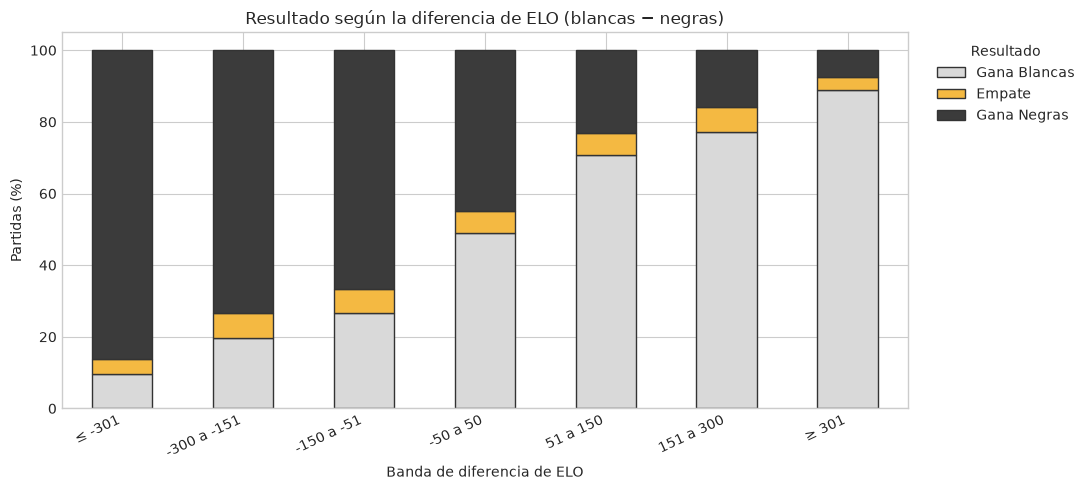

In [8]:
elo_bins = [-np.inf, -300, -150, -50, 50, 150, 300, np.inf]
elo_labels = ["≤ -301", "-300 a -151", "-150 a -51", "-50 a 50", "51 a 150", "151 a 300", "≥ 301"]
elo_band = pd.cut(df["diferencia_elo"], bins=elo_bins, labels=elo_labels)
h1_table = (
    pd.crosstab(elo_band, df["resultado"], normalize="index")
    .reindex(columns=RESULT_ORDER)
    .mul(100)
)
h1_cramers_v = cramers_v(elo_band, df["resultado"])
print(f"V de Cramér = {h1_cramers_v:.3f} — zona {correlation_zone(h1_cramers_v)}")
display(h1_table)

ax = h1_table.plot.bar(
    stacked=True, figsize=(11, 5), color=[COLORS[column] for column in h1_table.columns], edgecolor="#333333"
)
ax.set(
    title="Resultado según la diferencia de ELO (blancas − negras)",
    xlabel="Banda de diferencia de ELO",
    ylabel="Partidas (%)",
)
ax.legend(title="Resultado", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

**Resultado: V de Cramér = 0,234, zona amarilla. Decisión: confirmada con matiz.** La transición visual sigue la dirección esperada y el rating aporta señal real, pero no explica por sí solo el resultado: aun con más de 300 puntos de diferencia, el favorito gana el 88,9 % de las veces y no el 100 %. `diferencia_elo` queda como predictor candidato, sujeto a la limitación de fuga temporal del rating explicada en la sección 9.

## 6 · H2 — Paridad de ELO y duración

| Campo | Definición previa al cálculo |
|---|---|
| Afirmación | Las partidas con menor diferencia absoluta de ELO tienden a durar más. |
| Qué esperamos ver | Correlación negativa entre `abs(diferencia_elo)` y `cantidad_jugadas`. |
| Medidas | Pearson y Spearman. |
| Gráfico | Muestra reproducible de puntos y mediana por bandas de 50 puntos. |
| Regla de decisión | Se descarta para duración si ambas correlaciones quedan en zona roja. |

Pearson = -0.025 — 🔴 roja
Spearman = 0.031 — 🔴 roja


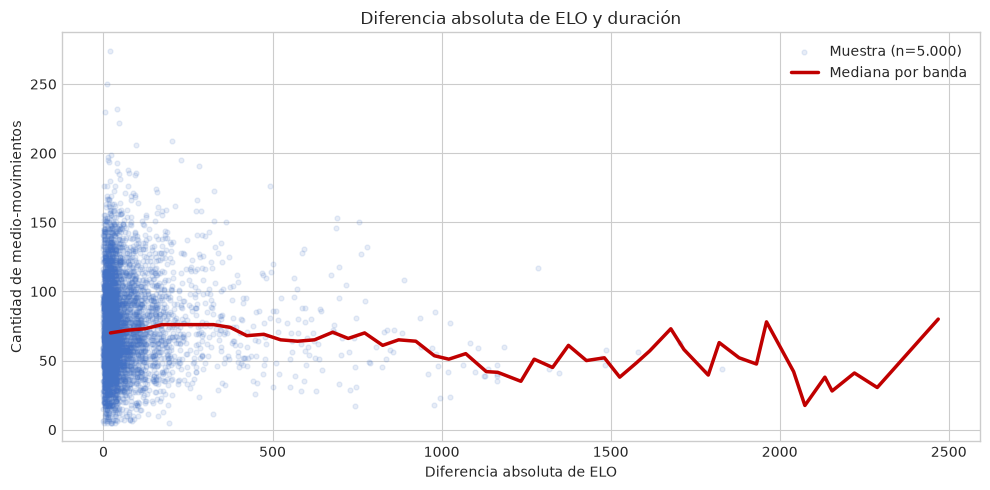

In [9]:
abs_elo_difference = df["diferencia_elo"].abs().rename("abs_diferencia_elo")
h2_pearson = abs_elo_difference.corr(df["cantidad_jugadas"], method="pearson")
h2_spearman = abs_elo_difference.corr(df["cantidad_jugadas"], method="spearman")
h2_frame = pd.DataFrame(
    {"abs_diferencia_elo": abs_elo_difference, "cantidad_jugadas": df["cantidad_jugadas"]}
)
sample = h2_frame.sample(n=min(5_000, len(h2_frame)), random_state=RANDOM_STATE)
max_bin = int(np.ceil(abs_elo_difference.max() / 50) * 50 + 50)
difference_bands = pd.cut(abs_elo_difference, bins=np.arange(0, max_bin + 1, 50), include_lowest=True)
binned_duration = h2_frame.groupby(difference_bands, observed=True).agg(
    diferencia_media=("abs_diferencia_elo", "mean"),
    duracion_mediana=("cantidad_jugadas", "median"),
    partidas=("cantidad_jugadas", "size"),
)

print(f"Pearson = {h2_pearson:.3f} — {correlation_zone(h2_pearson)}")
print(f"Spearman = {h2_spearman:.3f} — {correlation_zone(h2_spearman)}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sample["abs_diferencia_elo"], sample["cantidad_jugadas"], alpha=0.12, s=12, color="#4472c4", label="Muestra (n=5.000)")
ax.plot(binned_duration["diferencia_media"], binned_duration["duracion_mediana"], color="#c00000", linewidth=2.5, label="Mediana por banda")
ax.set(
    title="Diferencia absoluta de ELO y duración",
    xlabel="Diferencia absoluta de ELO",
    ylabel="Cantidad de medio-movimientos",
)
ax.legend()
plt.tight_layout()
plt.show()

**Resultado: Pearson = −0,025 y Spearman = 0,031, zona roja. Decisión: refutada.** Las dos medidas ni siquiera coinciden en el signo, y ambas magnitudes están por debajo de 0,05 sobre 80.145 partidas: no hay ni una relación lineal ni una monótona aprovechable. La paridad de rating no aporta una relación útil con la duración y `abs_diferencia_elo` no entra en ese modelo.

## 7 · H3 — Ritmo y terminación por tiempo

| Campo | Definición previa al cálculo |
|---|---|
| Afirmación | Bullet termina por tiempo en mayor proporción que Blitz y Rapid. |
| Qué esperamos ver | Orden Bullet > Blitz > Rapid. |
| Medida | η² de la indicadora `Termination == 'time'` agrupada por `TimeClass`. |
| Gráfico | Porcentaje de terminaciones por tiempo en cada modalidad. |
| Regla de decisión | Se confirma si el orden esperado aparece y el efecto no queda en rojo. |

η² = 0.065 — zona 🟡 amarilla


,partidas,porcentaje
TimeClass,,
bullet,21387,40.782
blitz,45403,22.943
rapid,13355,7.173


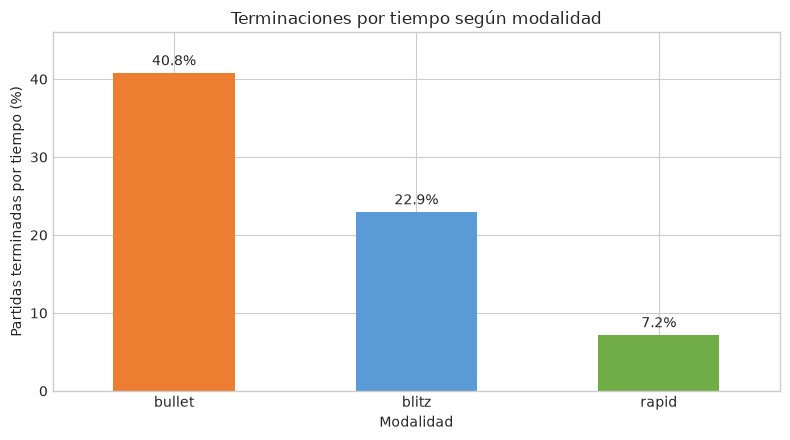

In [10]:
is_time_termination = df["Termination"].astype("string").str.lower().eq("time").astype(int)
h3_table = (
    pd.DataFrame({"TimeClass": df["TimeClass"].astype("string"), "termina_por_tiempo": is_time_termination})
    .groupby("TimeClass")["termina_por_tiempo"]
    .agg(partidas="size", proporcion="mean")
    .reindex(TIME_ORDER)
)
h3_table["porcentaje"] = h3_table["proporcion"].mul(100)
h3_eta = eta_squared(is_time_termination, df["TimeClass"])
print(f"η² = {h3_eta:.3f} — zona {eta_zone(h3_eta)}")
display(h3_table[["partidas", "porcentaje"]])

ax = h3_table["porcentaje"].plot.bar(figsize=(8, 4.5), color=["#ed7d31", "#5b9bd5", "#70ad47"])
ax.set(title="Terminaciones por tiempo según modalidad", xlabel="Modalidad", ylabel="Partidas terminadas por tiempo (%)")
ax.set_ylim(0, 46)
for index, value in enumerate(h3_table["porcentaje"]):
    ax.text(index, value + 1, f"{value:.1f}%", ha="center")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Resultado: Bullet 40,8 %, Blitz 22,9 %, Rapid 7,2 %; η² = 0,065, zona amarilla. Decisión: confirmada.** El orden esperado se sostiene con un efecto moderado: terminar por tiempo es casi seis veces más frecuente en Bullet que en Rapid. Esto describe el mecanismo de finalización, pero `Termination` sólo existe después de la partida y no puede usarse para predecir un resultado pre-partida.

## 8 · H4 — Familia de apertura y duración

| Campo | Definición previa al cálculo |
|---|---|
| Afirmación | Las aperturas cerradas producen partidas más largas que las semiabiertas. |
| Qué esperamos ver | Separación clara de `cantidad_jugadas` entre familias. |
| Medida | η² de duración agrupada por `familia_apertura`. |
| Gráfico | Boxplot por familia, sin ocultar el tamaño de cada grupo. |
| Regla de decisión | No entra al baseline si η² queda en zona roja. |

η² = 0.007 — zona 🔴 roja


,partidas,media,mediana
familia_apertura,,,
Abierta,19119,70.797,66.000
Semiabierta,25359,75.186,71.000
Cerrada,10624,76.832,72.000
India,3537,81.446,76.000
Flanco,21506,77.400,74.000


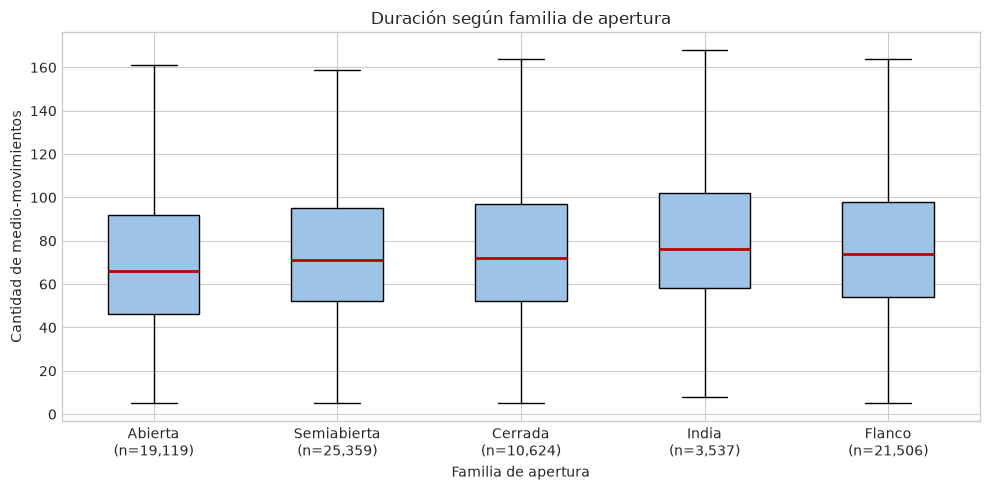

In [11]:
family_order = ["Abierta", "Semiabierta", "Cerrada", "India", "Flanco"]
h4_table = (
    df.groupby("familia_apertura", observed=True)["cantidad_jugadas"]
    .agg(partidas="size", media="mean", mediana="median")
    .reindex(family_order)
)
h4_eta = eta_squared(df["cantidad_jugadas"], df["familia_apertura"])
print(f"η² = {h4_eta:.3f} — zona {eta_zone(h4_eta)}")
display(h4_table)

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(
    [df.loc[df["familia_apertura"] == family, "cantidad_jugadas"] for family in family_order],
    tick_labels=[f"{family}\n(n={int(h4_table.loc[family, 'partidas']):,})" for family in family_order],
    showfliers=False,
    patch_artist=True,
    boxprops={"facecolor": "#9dc3e6"},
    medianprops={"color": "#c00000", "linewidth": 2},
)
ax.set(title="Duración según familia de apertura", xlabel="Familia de apertura", ylabel="Cantidad de medio-movimientos")
plt.tight_layout()
plt.show()

**Resultado: η² = 0,007, zona roja. Decisión: refutada como predictor del baseline.** Cerrada tiene una media algo mayor que Semiabierta (76,8 frente a 75,2 plies), así que la dirección de la afirmación se sostiene, pero la familia explica menos del 1 % de la variabilidad. La familia más larga es India (81,4 plies), y es también la más chica: 3.537 partidas contra 25.359 de Semiabierta. Además, la apertura sólo se conoce después de jugar los primeros movimientos. Queda como experimento separado para un escenario explícitamente post-apertura.

## 9 · Columnas candidatas y control de fuga

La tabla siguiente es el puente hacia la Entrega 3. Se separa la evidencia observada de la decisión de diseño: una variable puede entrar porque forma parte de la pregunta de investigación aunque su asociación bivariada sea débil. La pregunta decisiva de fuga es si existiría en el momento real de predecir, antes de comenzar la partida.

In [12]:
target_associations = {
    "elo_promedio": (
        df["elo_promedio"].corr(df["cantidad_jugadas"], method="pearson"),
        df["elo_promedio"].corr(df["cantidad_jugadas"], method="spearman"),
    ),
    "tiempo_base_seg": (
        df["tiempo_base_seg"].astype(float).corr(df["cantidad_jugadas"], method="pearson"),
        df["tiempo_base_seg"].astype(float).corr(df["cantidad_jugadas"], method="spearman"),
        cramers_v(df["tiempo_base_seg"], df["resultado"]),
    ),
    "incremento_seg": (
        df["incremento_seg"].astype(float).corr(df["cantidad_jugadas"], method="pearson"),
        df["incremento_seg"].astype(float).corr(df["cantidad_jugadas"], method="spearman"),
        cramers_v(df["incremento_seg"], df["resultado"]),
    ),
    "TimeClass": (
        eta_squared(df["cantidad_jugadas"], df["TimeClass"]),
        cramers_v(df["TimeClass"], df["resultado"]),
    ),
}

candidate_columns = pd.DataFrame(
    [
        ("diferencia_elo", "Balance de rating por color", f"V resultado = {h1_cramers_v:.3f}", "Entra con advertencia", "Parcial: el rating disponible es posterior a la partida"),
        ("elo_promedio", "Nivel general de la partida", f"r duración = {target_associations['elo_promedio'][0]:.3f} / {target_associations['elo_promedio'][1]:.3f}", "Entra con advertencia", "Parcial: misma fuga temporal del rating"),
        ("tiempo_base_seg", "Segundos iniciales", f"r duración = {target_associations['tiempo_base_seg'][0]:.3f} / {target_associations['tiempo_base_seg'][1]:.3f}; V resultado = {target_associations['tiempo_base_seg'][2]:.3f}", "Entra por dominio; evaluar aporte incremental", "Sí"),
        ("incremento_seg", "Incremento por jugada", f"r duración = {target_associations['incremento_seg'][0]:.3f} / {target_associations['incremento_seg'][1]:.3f}; V resultado = {target_associations['incremento_seg'][2]:.3f}", "Entra por dominio; evaluar aporte incremental", "Sí"),
        ("TimeClass", "Modalidad oficial", f"η² duración = {target_associations['TimeClass'][0]:.3f}; V resultado = {target_associations['TimeClass'][1]:.3f}", "Entra por la pregunta de investigación", "Sí"),
        ("Date", "Fecha de la partida", "No aplica: variable de partición", "Se usa para partición temporal", "Sí; no como predictor crudo"),
        ("familia_apertura", "Familia ECO", f"η² duración = {h4_eta:.3f}", "Sale del baseline", "No: se conoce después de iniciar la partida"),
        ("ECO / Opening", "Apertura detallada", "No se evalúa: alta cardinalidad", "Sale del baseline", "No: se conoce después de iniciar la partida"),
        ("Termination", "Motivo de finalización", "No aplica: fuga post-partida", "Sale por fuga", "No: se completa cuando la partida termina"),
        ("Result", "Resultado PGN", "No aplica: duplicado del target", "Sale por fuga", "No: es el target en otro formato"),
        ("moves_text", "Secuencia completa de jugadas", "No aplica: fuga post-partida", "Sale del modelo pre-partida", "No: contiene toda la partida"),
        ("GameUrl", "Identificador único", "No aplica: cardinalidad total", "Sale", "Sí, pero no aporta señal"),
        ("White / Black", "Identidad de los jugadores", "No se usa en el modelo general", "Sale del modelo general", "Sí, pero permitiría memorizar jugadores"),
        ("WhiteElo / BlackElo", "Rating crudo por color", "Redundancia matemática", "Salen si entran media y diferencia", "Parcial: misma fuga temporal del rating"),
        ("Event / Variant / Rated", "Campos de auditoría", "Varianza cero", "Salen", "Sí, pero no aportan información"),
    ],
    columns=["columna", "que_mide", "evidencia_eda", "decision", "existiria_al_predecir"],
)
display(candidate_columns)

,columna,que_mide,evidencia_eda,decision,existiria_al_predecir
0,diferencia_elo,Balance de rating por color,V resultado = 0.234,Entra con advertencia,Parcial: el rating disponible es posterior a la partida
1,elo_promedio,Nivel general de la partida,r duración = 0.230 / 0.225,Entra con advertencia,Parcial: misma fuga temporal del rating
2,tiempo_base_seg,Segundos iniciales,r duración = -0.086 / -0.078; V resultado = 0.047,Entra por dominio; evaluar aporte incremental,Sí
3,incremento_seg,Incremento por jugada,r duración = -0.035 / -0.037; V resultado = 0.021,Entra por dominio; evaluar aporte incremental,Sí
4,TimeClass,Modalidad oficial,η² duración = 0.009; V resultado = 0.030,Entra por la pregunta de investigación,Sí
5,Date,Fecha de la partida,No aplica: variable de partición,Se usa para partición temporal,Sí; no como predictor crudo
6,familia_apertura,Familia ECO,η² duración = 0.007,Sale del baseline,No: se conoce después de iniciar la partida
7,ECO / Opening,Apertura detallada,No se evalúa: alta cardinalidad,Sale del baseline,No: se conoce después de iniciar la partida
8,Termination,Motivo de finalización,No aplica: fuga post-partida,Sale por fuga,No: se completa cuando la partida termina
9,Result,Resultado PGN,No aplica: duplicado del target,Sale por fuga,No: es el target en otro formato


### Dos escenarios que no deben mezclarse

1. **Baseline pre-partida:** modalidad, control de tiempo y ratings (estos últimos con la fuga conocida declarada). No usa apertura, terminación, jugadas ni resultado PGN.
2. **Experimento post-apertura:** puede incorporar `ECO`, `Opening` o `familia_apertura`, pero debe formularse como otra pregunta y compararse contra el baseline.

Para evaluar ambos objetivos se reservarán las partidas más recientes como prueba usando `Date`; una partición aleatoria permitiría que patrones temporales muy próximos aparezcan a ambos lados y daría una estimación demasiado optimista.

## 10 · Verificación final y conclusiones

El cierre comprueba automáticamente los supuestos de integridad usados durante el análisis. Las partidas del límite UTC del 1 de septiembre se validan como el único día conocido fuera del mes nominal; no se borran ni se ocultan.

In [13]:
required_columns = {
    "GameUrl", "Date", "resultado", "cantidad_jugadas", "diferencia_elo",
    "elo_promedio", "TimeClass", "Termination", "familia_apertura",
}
assert required_columns.issubset(df.columns), "Faltan columnas necesarias para el EDA"
assert len(df) > 10_000, "El volumen no alcanza el criterio recomendado de la cátedra"
assert df["GameUrl"].is_unique, "GameUrl debe identificar una sola partida"
assert df["GameUrl"].notna().all(), "La clave no puede tener nulos"
assert df[["resultado", "cantidad_jugadas"]].notna().all().all(), "Los objetivos no pueden tener nulos"
assert set(df["resultado"].astype(str)) == set(RESULT_ORDER), "Apareció una clase de resultado inesperada"
assert set(df["TimeClass"].astype(str)) == set(TIME_ORDER), "Apareció una modalidad fuera del alcance"
assert df["cantidad_jugadas"].ge(5).all(), "Hay partidas por debajo del mínimo de plies"
assert df[["WhiteElo", "BlackElo"]].gt(0).all().all(), "Los ratings deben ser positivos"
assert len(monthly_boundary) > 0, "Se esperaba observar el límite UTC del archivo mensual"
assert monthly_boundary["Date"].eq(pd.Timestamp("2026-09-01")).all(), "Apareció otra fecha fuera del límite mensual conocido"
assert h1_cramers_v >= 0.10, "H1 dejó de tener asociación moderada"
assert abs(h2_pearson) < 0.10 and abs(h2_spearman) < 0.10, "H2 cambió de zona"
assert h3_eta >= 0.06, "H3 dejó de tener efecto moderado"
assert h4_eta < 0.06, "H4 cambió de zona"

print("✓ Notebook ejecutado de punta a punta")
print("✓ Clave única, objetivos completos y dominios válidos")
print("✓ Cuatro hipótesis con medida, gráfico, zona y decisión")
print("✓ Tabla de columnas candidatas con control de fuga")
print("✓ Anomalía temporal investigada y conservada")

✓ Notebook ejecutado de punta a punta
✓ Clave única, objetivos completos y dominios válidos
✓ Cuatro hipótesis con medida, gráfico, zona y decisión
✓ Tabla de columnas candidatas con control de fuga
✓ Anomalía temporal investigada y conservada


### Resultado de la entrega

- El dataset tiene volumen suficiente, clave única y objetivos completos.
- `resultado` está equilibrado entre victorias blancas y negras, pero Empate es minoritaria y exige métricas por clase.
- La diferencia de ELO ofrece señal moderada para el resultado; la paridad de ELO no explica la duración.
- La modalidad está asociada de forma moderada con terminar por tiempo.
- La familia de apertura explica muy poco de la duración y no pertenece al baseline pre-partida.
- La Entrega 3 debe comenzar con una partición temporal y comparar un baseline pre-partida contra cualquier escenario post-apertura, manteniendo visible la fuga del rating informado por Chess.com.